# DBSCAN — Density-Based Spatial Clustering of Applications with Noise

## 1. Definition
DBSCAN is an **unsupervised clustering algorithm** that groups together points that are closely packed (i.e., have many nearby neighbors) while marking points that lie alone in low-density regions as **outliers (noise)**.

**Key difference from K-Means and Agglomerative Clustering:**  
DBSCAN does **not** require specifying the number of clusters beforehand.

---

## 2. Key Concepts

- **Epsilon (ε)**: Radius of the neighborhood around a point.
- **MinPts**: Minimum number of points required to form a dense region.
- **Core Point**: Has at least `MinPts` points within distance `ε`.
- **Border Point**: Lies within `ε` of a core point but has fewer than `MinPts` neighbors.
- **Noise Point**: Not a core point and not directly reachable from one.

---

## 3. Algorithm Steps

1. Choose parameters **ε** and **MinPts**.
2. For each **unvisited point**:
   - Mark it as visited.
   - Retrieve its **ε-neighborhood**.
   - If it contains at least **MinPts** points → mark as **core point** and start a new cluster.
   - Expand the cluster by recursively visiting all points within **ε**.
3. Points not reachable from any cluster are marked as **noise**.

---

## 4. Mathematical Definitions

- **Neighborhood of a point** `p`:
  
Nε(p) = { q ∈ D | distance(p, q) ≤ ε }

- **Core point condition**:

|Nε(p)| ≥ MinPts



---

## 5. Advantages
- Automatically detects the **number of clusters**.
- Can find clusters of **arbitrary shapes**.
- Handles **noise/outliers** well.

---

## 6. Disadvantages
- Performance depends heavily on the choice of **ε** and **MinPts**.
- Struggles with clusters of **varying densities**.



/var/folders/kn/vfmfhg9s4dd9bmtj8tg4gjpm0000gn/T/ipykernel_4103/3174252921.py:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xy[:, 0], xy[:, 1], marker='x', s=50, c=[col], edgecolors='k')


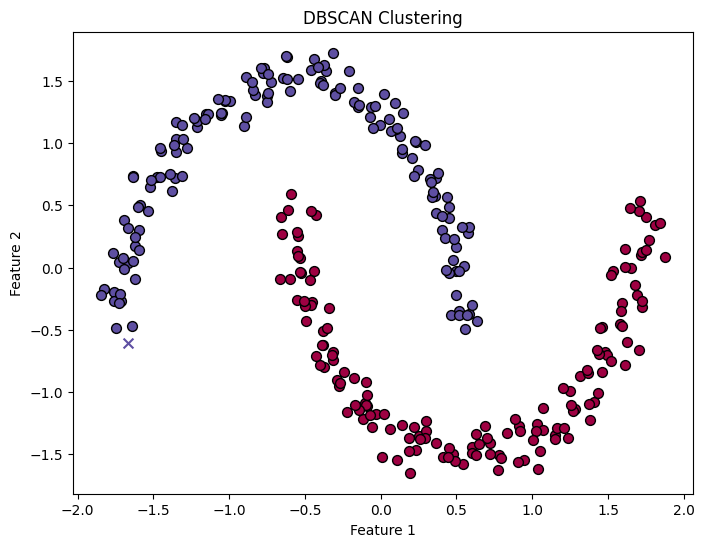

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Generate synthetic data
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. Standardize the features
X_scaled = StandardScaler().fit_transform(X)

# 3. Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)  # eps = ε, min_samples = MinPts
labels = dbscan.fit_predict(X_scaled)

# 4. Identify core, border, and noise points
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
unique_labels = set(labels)

# 5. Plot clusters
plt.figure(figsize=(8, 6))
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black for noise
        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], marker='o', s=50, c=[col], edgecolors='k')
    
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], marker='x', s=50, c=[col], edgecolors='k')

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
